In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load dataset Iris bawaan sklearn
iris = load_iris()
X = iris.data
y = iris.target

print(f"Total sampel data: {X.shape[0]}")
print(f"Jumlah fitur/atribut: {X.shape[1]}")
print(f"Nama kelas: {iris.target_names}")


Total sampel data: 150
Jumlah fitur/atribut: 4
Nama kelas: ['setosa' 'versicolor' 'virginica']


In [2]:
# Memanggil KNNManual dari file knn_manual.py yang sejajar
from knn_manual import KNNManual

print("Berhasil mengimpor KNNManual!")

Berhasil mengimpor KNNManual!


In [3]:
# Membagi data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Uji menggunakan KNN Manual kita (K=3)
knn_manual = KNNManual(k=3)
knn_manual.fit(X_train, y_train)
prediksi_manual = knn_manual.predict(X_test)
akurasi_manual = accuracy_score(y_test, prediksi_manual)

# 2. Uji menggunakan KNN Sklearn (K=3)
knn_sklearn = KNeighborsClassifier(n_neighbors=3)
knn_sklearn.fit(X_train, y_train)
prediksi_sklearn = knn_sklearn.predict(X_test)
akurasi_sklearn = accuracy_score(y_test, prediksi_sklearn)

print(f"Hasil Prediksi Manual : {prediksi_manual}")
print(f"Hasil Prediksi Sklearn: {prediksi_sklearn}")
print("-" * 50)
print(f"Akurasi KNN Manual : {akurasi_manual * 100:.2f}%")
print(f"Akurasi KNN Sklearn: {akurasi_sklearn * 100:.2f}%")

Hasil Prediksi Manual : [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Hasil Prediksi Sklearn: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
--------------------------------------------------
Akurasi KNN Manual : 100.00%
Akurasi KNN Sklearn: 100.00%


In [4]:
# Daftar nilai K sesuai instruksi soal
daftar_k = [1, 3, 5, 7, 10, 15]

# Siapkan 5-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# List untuk menyimpan rata-rata akurasi tiap K
rata_akurasi_manual = []
rata_akurasi_sklearn = []

print("Memulai Evaluasi 5-Fold Cross Validation...\n")

for k in daftar_k:
    skor_fold_manual = []
    skor_fold_sklearn = []
    
    # Looping melewati 5 pasang Train-Validation Fold
    for train_idx, val_idx in kf.split(X):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Evaluasi Manual
        model_manual = KNNManual(k=k)
        model_manual.fit(X_train_fold, y_train_fold)
        pred_manual = model_manual.predict(X_val_fold)
        skor_fold_manual.append(accuracy_score(y_val_fold, pred_manual))
        
        # Evaluasi Sklearn
        model_sklearn = KNeighborsClassifier(n_neighbors=k)
        model_sklearn.fit(X_train_fold, y_train_fold)
        pred_sklearn = model_sklearn.predict(X_val_fold)
        skor_fold_sklearn.append(accuracy_score(y_val_fold, pred_sklearn))
        
    # Hitung rata-rata akurasi
    rata_manual = np.mean(skor_fold_manual)
    rata_sklearn = np.mean(skor_fold_sklearn)
    
    rata_akurasi_manual.append(rata_manual)
    rata_akurasi_sklearn.append(rata_sklearn)
    
    print(f"K = {k:2d} | Rata-rata Akurasi Manual: {rata_manual*100:.2f}% | Sklearn: {rata_sklearn*100:.2f}%")

Memulai Evaluasi 5-Fold Cross Validation...

K =  1 | Rata-rata Akurasi Manual: 96.00% | Sklearn: 96.00%
K =  3 | Rata-rata Akurasi Manual: 96.67% | Sklearn: 96.67%
K =  5 | Rata-rata Akurasi Manual: 97.33% | Sklearn: 97.33%
K =  7 | Rata-rata Akurasi Manual: 97.33% | Sklearn: 97.33%
K = 10 | Rata-rata Akurasi Manual: 97.33% | Sklearn: 97.33%
K = 15 | Rata-rata Akurasi Manual: 97.33% | Sklearn: 97.33%


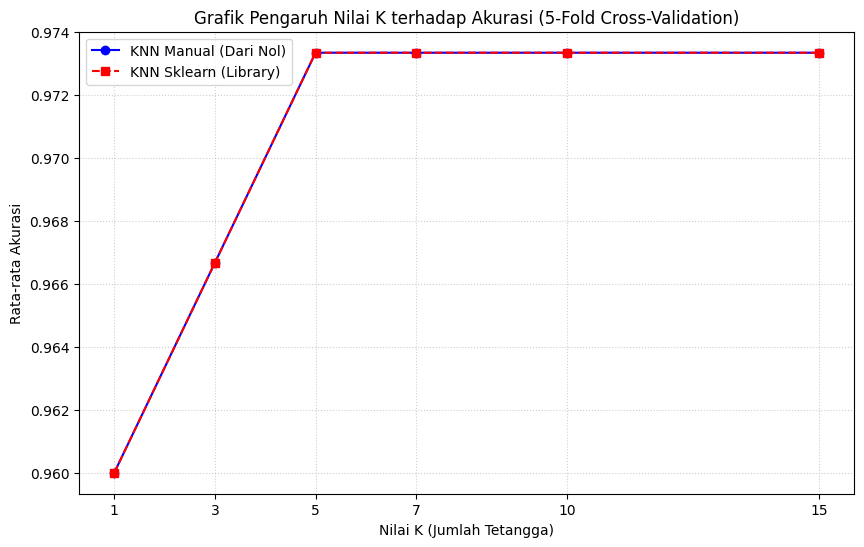

In [5]:
# Membuat Plot Grafik Line Chart
plt.figure(figsize=(10, 6))
plt.plot(daftar_k, rata_akurasi_manual, marker='o', linestyle='-', color='b', label='KNN Manual (Dari Nol)')
plt.plot(daftar_k, rata_akurasi_sklearn, marker='s', linestyle='--', color='r', label='KNN Sklearn (Library)')

plt.title('Grafik Pengaruh Nilai K terhadap Akurasi (5-Fold Cross-Validation)')
plt.xlabel('Nilai K (Jumlah Tetangga)')
plt.ylabel('Rata-rata Akurasi')
plt.xticks(daftar_k)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()